# Final Evaluation and Interpretation

This notebook evaluates the frozen tuned XGBoost pipeline once on the untouched FY2019 test set.

The model, hyperparameters, preprocessing pipeline, and classification threshold were selected using data through FY2018. No model-selection or threshold changes will be made after viewing FY2019 results.

In [16]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)



FEATURES_PATH = "../data/processed/sba_7a_features.csv"
MODEL_PATH = "../models/tuned_xgboost_pipeline.joblib"
FIGURES_DIR = Path("../reports/figures")

TARGET_COL = "default"
TEST_YEAR = 2019
RANDOM_STATE = 42

## Load the frozen model artifact

The artifact contains the trained FY2010–FY2017 pipeline, selected model name, locked threshold, validation metrics, and expected feature columns.

In [17]:
model_artifact = joblib.load(MODEL_PATH)

selected_model_name = model_artifact["model_name"]
selected_model = model_artifact["pipeline"]
selected_threshold = model_artifact["threshold"]
feature_columns = model_artifact["feature_columns"]

print(f"Model: {selected_model_name}")
print(f"Locked threshold: {selected_threshold:.4f}")
print(f"Training period: {model_artifact['training_period']}")
print(f"Validation period: {model_artifact['validation_period']}")

Model: Tuned XGBoost
Locked threshold: 0.7482
Training period: FY2010-FY2017
Validation period: FY2018


## Load FY2019 test data

FY2019 was not used for model comparison, hyperparameter tuning, or threshold selection.

In [18]:
df = pd.read_csv(
    FEATURES_PATH,
    dtype={
        "naics_sector": "string",
        "CongressionalDistrict": "string",
        "approval_month": "string",
    },
    low_memory=False,
)

test_df = df.loc[df["ApprovalFY"] == TEST_YEAR].copy()

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

missing_features = set(feature_columns) - set(X_test.columns)
unexpected_features = set(X_test.columns) - set(feature_columns)

assert not missing_features, (
    f"Test data is missing expected features: {missing_features}"
)
assert not unexpected_features, (
    f"Test data contains unexpected features: {unexpected_features}"
)

X_test = X_test.loc[:, feature_columns]

print(f"FY2019 test loans: {len(X_test):,}")
print(f"FY2019 charge-off rate: {y_test.mean():.2%}")

FY2019 test loans: 31,606
FY2019 charge-off rate: 9.67%


## Final FY2019 evaluation

The frozen pipeline produces charge-off probabilities. The locked FY2018 F1-maximizing threshold is applied without modification.

In [19]:
test_probabilities = selected_model.predict_proba(X_test)[:,1]
test_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

test_metrics = {
    "pr_auc": average_precision_score(y_test, test_probabilities),
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "precision": precision_score(y_test, test_predictions),
    "recall": recall_score(y_test, test_predictions),
    "f1": f1_score(y_test, test_predictions),
    "brier_score": brier_score_loss(y_test, test_probabilities),
}

test_metrics_df = pd.DataFrame(
    [test_metrics],
    index=["FY2019 test set"],
)

test_metrics_df.round(4)

,pr_auc,roc_auc,precision,recall,f1,brier_score
FY2019 test set,0.775,0.946,0.7389,0.7082,0.7232,0.0518


In [20]:
validation_vs_test_df = pd.DataFrame(
    {
        "FY2018 validation": {
            "pr_auc": model_artifact["validation_pr_auc"],
            "f1": model_artifact["validation_f1"],
        },
        "FY2019 test": {
            "pr_auc": test_metrics["pr_auc"],
            "f1": test_metrics["f1"],
        },
    }
).T

validation_vs_test_df.round(4)

,pr_auc,f1
FY2018 validation,0.8257,0.7823
FY2019 test,0.7750,0.7232


## Classification performance

Precision and recall are evaluated at the locked threshold. PR-AUC and ROC-AUC assess ranking performance across all possible thresholds.

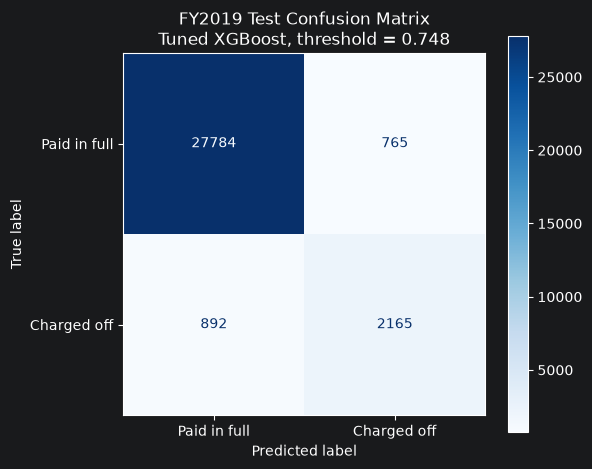

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Paid in full", "Charged off"],
    cmap="Blues",
    ax=ax,
)

ax.set_title(
    f"FY2019 Test Confusion Matrix\n"
    f"{selected_model_name}, threshold = {selected_threshold:.3f}"
)

fig.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "fy2019_confusion_matrix.png", dpi=200)
plt.show()

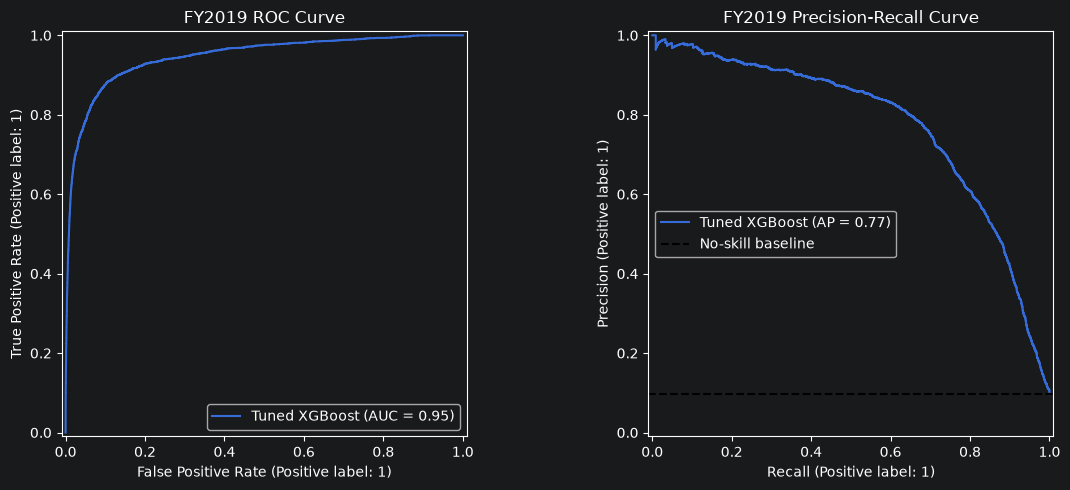

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_model_name,
    ax=axes[0],
)

axes[0].set_title("FY2019 ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_model_name,
    ax=axes[1],
)

axes[1].axhline(
    y=y_test.mean(),
    color="black",
    linestyle="--",
    label="No-skill baseline",
)

axes[1].set_title("FY2019 Precision-Recall Curve")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fy2019_roc_pr_curves.png", dpi=200)
plt.show()

## Calibration

Calibration checks whether predicted probabilities correspond to observed charge-off frequencies. A well-calibrated model lies near the diagonal reference line.

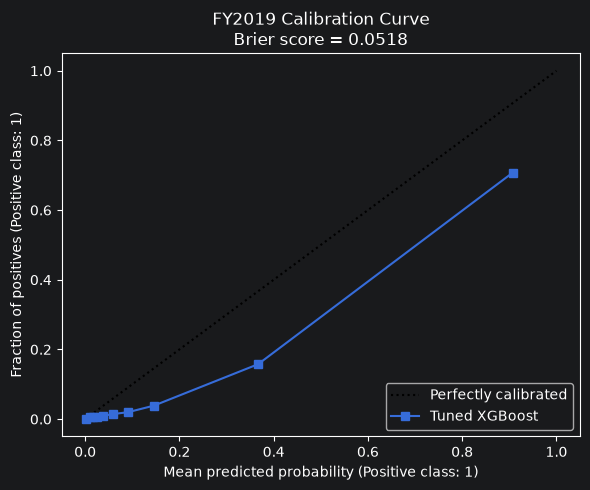

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))

CalibrationDisplay.from_predictions(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile",
    name=selected_model_name,
    ax=ax,
)

ax.set_title(
    f"FY2019 Calibration Curve\n"
    f"Brier score = {test_metrics['brier_score']:.4f}"
)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fy2019_calibration_curve.png", dpi=200)
plt.show()

## Global feature importance

XGBoost feature importance summarizes how often and how effectively transformed features contribute to tree splits. Importance indicates predictive association, not a causal relationship with charge-off risk.

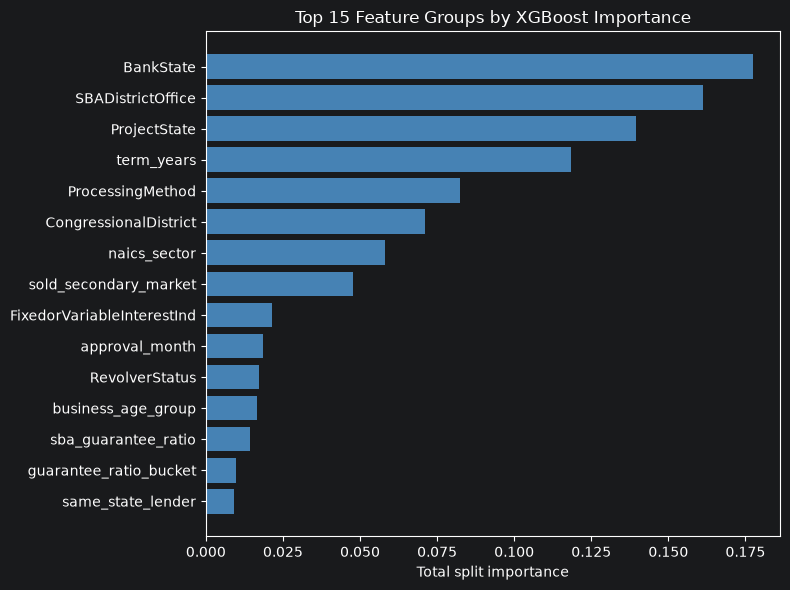

,source_feature,importance
1,BankState,0.177343
11,SBADistrictOffice,0.161140
9,ProjectState,0.139652
22,term_years,0.118575
8,ProcessingMethod,0.082313
4,CongressionalDistrict,0.071106
18,naics_sector,0.058181
21,sold_secondary_market,0.047817
5,FixedorVariableInterestInd,0.021314
12,approval_month,0.018671


In [24]:
preprocessor = selected_model.named_steps["preprocessor"]
classifier = selected_model.named_steps["classifier"]

transformed_feature_names = preprocessor.get_feature_names_out()
feature_importances = classifier.feature_importances_

importance_df = pd.DataFrame(
    {
        "transformed_feature": transformed_feature_names,
        "importance": feature_importances,
    }
)


def get_source_feature(transformed_feature):
    feature = transformed_feature.split("__", maxsplit=1)[-1]

    if feature.startswith("missingindicator_"):
        return feature.replace("missingindicator_", "")

    for categorical_feature in sorted(
        preprocessor.transformers_[1][2],
        key=len,
        reverse=True,
    ):
        if feature.startswith(f"{categorical_feature}_"):
            return categorical_feature

    return feature


importance_df["source_feature"] = importance_df[
    "transformed_feature"
].map(get_source_feature)

grouped_importance_df = (
    importance_df
    .groupby("source_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

top_features = grouped_importance_df.head(15).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    top_features["source_feature"],
    top_features["importance"],
    color="steelblue",
)

ax.set_title("Top 15 Feature Groups by XGBoost Importance")
ax.set_xlabel("Total split importance")
ax.set_ylabel("")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fy2019_feature_importance.png", dpi=200)
plt.show()

grouped_importance_df.to_csv(
    "../reports/fy2019_grouped_feature_importance.csv",
    index=False,
)

grouped_importance_df.head(15)

## SHAP interpretation

SHAP values explain how each transformed feature shifts an individual prediction relative to the model's average prediction.

To keep computation manageable, SHAP is calculated on a random sample of 1,000 FY2019 loans. These explanations describe model behavior, not causal effects.

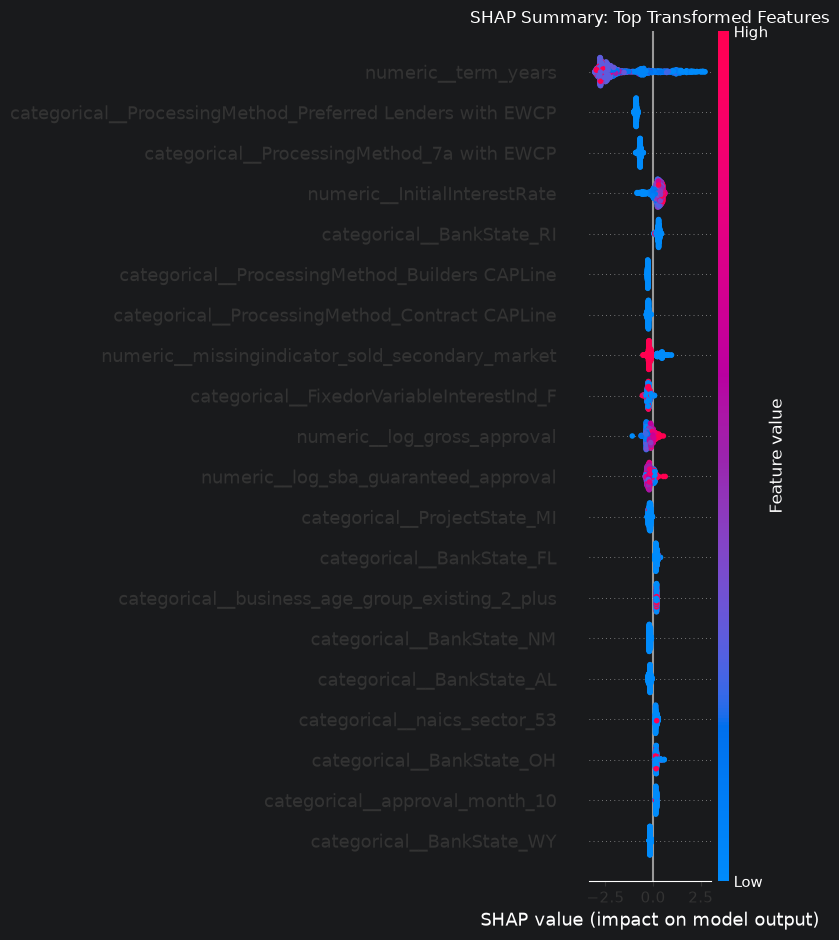

In [25]:
shap_sample = X_test.sample(
    n=min(1_000,len(X_test)),
    random_state=RANDOM_STATE,
)

shap_sample_processed = preprocessor.transform(shap_sample)

if hasattr(shap_sample_processed, "toarray"):
    shap_sample_processed = shap_sample_processed.toarray()

explainer = shap.TreeExplainer(classifier)

shap_values = explainer.shap_values(shap_sample_processed)

shap.summary_plot(
    shap_values,
    shap_sample_processed,
    feature_names=transformed_feature_names,
    max_display=20,
    show=False,
)

plt.title("SHAP Summary: Top Transformed Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fy2019_shap_summary.png", dpi=200)
plt.show()

In [26]:
metrics_path = Path("../reports/fy2019_test_metrics.csv")

test_metrics_df.to_csv(
    metrics_path,
    index_label="dataset",
)

print(f"Saved test metrics to: {metrics_path}")
print(f"Saved figures to: {FIGURES_DIR}")

Saved test metrics to: ..\reports\fy2019_test_metrics.csv
Saved figures to: ..\reports\figures


## Final Results and Limitations

The frozen tuned XGBoost pipeline was evaluated once on the untouched FY2019 test set using the threshold selected on FY2018 validation data.

### FY2019 test performance

- PR-AUC: 0.7750
- ROC-AUC: 0.9460
- Precision: 0.7389
- Recall: 0.7082
- F1: 0.7232
- Brier score: 0.0518

Performance declined relative to FY2018 validation, where PR-AUC was 0.8257 and F1 was 0.7823. This is expected when evaluating a frozen model on a later loan cohort and reinforces the value of the chronological evaluation design.

### Interpretation

The most influential grouped feature families were lender/project geography (`BankState`, `SBADistrictOffice`, and `ProjectState`), loan term, processing method, congressional district, and NAICS sector.

Feature importance and SHAP values describe predictive associations in this historical dataset. They do not establish that a feature causes loan charge-off.

### Limitations

- The dataset includes only loans with final observed outcomes, which may introduce outcome-observation bias for newer cohorts.
- The threshold was selected by maximizing validation-set F1. A real lending workflow should instead incorporate business costs, risk appetite, and review capacity.
- Geographic variables may capture regional conditions, lender practices, or historical program patterns that can change over time.
- Aggregated split importance can favor categorical feature families with many one-hot levels, so feature importance should be interpreted alongside the SHAP summary rather than as a causal ranking.
- This is an educational portfolio project, not a production credit-decision system.